# 08. Document NLP with OCR and Tesseract for Business Document Extraction


## 1. What you will build

- A synthetic invoice image generator using structured invoice records.
- An OCR extraction pipeline with Tesseract.
- A regex-based post-processing layer with measurable field-level accuracy.


## 2. When to use this in real companies

Use this approach when key document fields must be extracted from scans or PDFs, such as invoices, forms, and statements. This is common in finance operations, claims processing, and back-office automation.


## 3. Business goal

Extract critical invoice fields from OCR text (`vendor`, `invoice_number`, `invoice_date`, `due_date`, `customer`, `total_amount`) with repeatable evaluation.


## 4. Imports and setup


In [1]:
import os
import re
from pathlib import Path

import pandas as pd
import pytesseract
from dotenv import find_dotenv, load_dotenv
from PIL import Image, ImageDraw, ImageFilter, ImageFont


In [2]:
dotenv_path = find_dotenv(filename=".env", usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path=dotenv_path, override=False)

tesseract_from_env = os.getenv("TESSERACT_EXE", "").strip()
tesseract_exe = Path(tesseract_from_env)

if tesseract_exe.exists():
    pytesseract.pytesseract.tesseract_cmd = str(tesseract_exe)

try:
    print("Using Tesseract cmd:", pytesseract.pytesseract.tesseract_cmd)
    print("Tesseract version:", pytesseract.get_tesseract_version())
except Exception as exc:
    raise RuntimeError("Install Tesseract OCR and set TESSERACT_EXE in .env if needed: https://github.com/UB-Mannheim/tesseract/wiki") from exc

Using Tesseract cmd: C:\Users\AntonioBR\AppData\Local\Programs\Tesseract-OCR\tesseract.exe
Tesseract version: 5.5.0.20241111


## 5. Load invoice records from `data/08_data`


In [3]:
DATA_PATH = Path("../data/08_data/invoice_records.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/08_data/invoice_records.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Dataset not found: data/08_data/invoice_records.csv")

invoice_df = pd.read_csv(DATA_PATH)
invoice_df.head()


,invoice_id,vendor,address,invoice_date,due_date,customer,item_a,item_a_amount,item_b,item_b_amount,tax_rate,tax_amount,total_amount
0,INV-2026-0451,Northwind Services Ltd.,"42 Market Street, Madrid, Spain",2026-03-14,2026-04-14,Fabrikam Retail Europe,NLP Setup,820.0,Support Services,450.0,21%,266.7,1536.7
1,INV-2026-0518,Orion Data Consulting,"88 King Road, London, UK",2026-04-01,2026-05-01,Contoso Operations,Model Audit,950.0,Monitoring Setup,520.0,20%,294.0,1764.0
2,INV-2026-0607,Apex Automation GmbH,"12 Ring Avenue, Berlin, Germany",2026-05-11,2026-06-11,Litware Manufacturing,OCR Pipeline,1100.0,Maintenance Pack,600.0,19%,323.0,2023.0


## 6. Generate synthetic invoice image from structured data


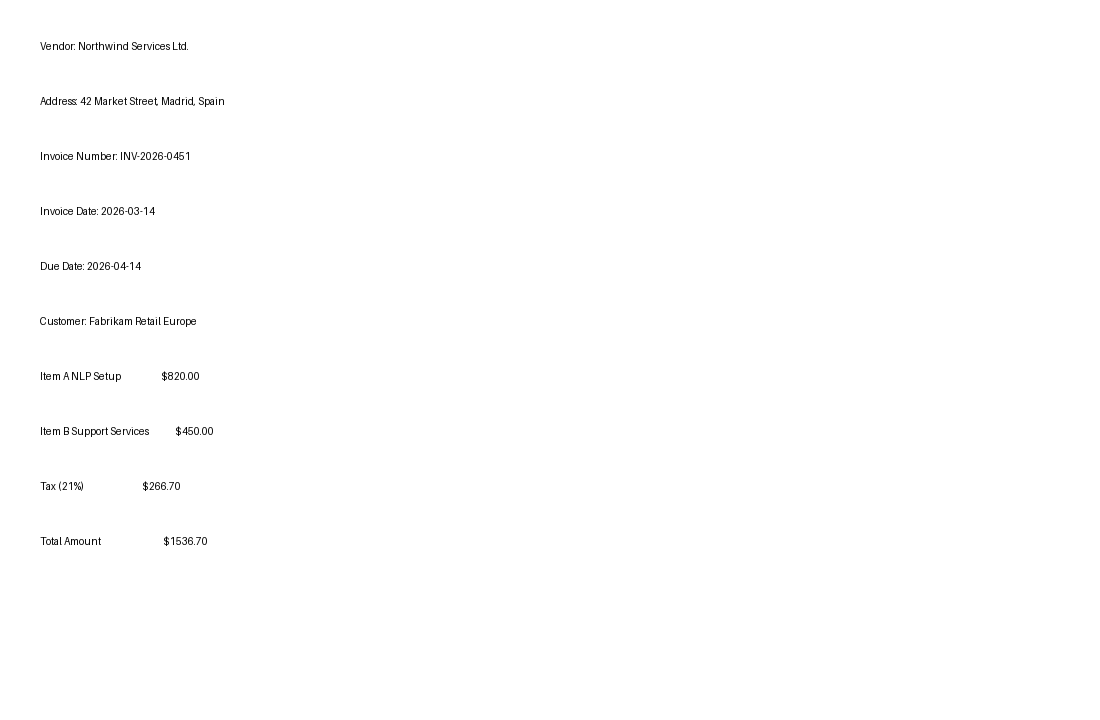

In [4]:
record = invoice_df.iloc[0].to_dict()

cwd = Path.cwd()
data_dir = cwd / "data" / "08_data" if (cwd / "data" / "08_data").exists() else cwd.parent / "data" / "08_data"
data_dir.mkdir(parents=True, exist_ok=True)
img_path = data_dir / f"{record['invoice_id']}_ocr.png"


def make_invoice_image(row: dict, out_path: Path):
    """Render one invoice image from structured invoice fields."""
    img = Image.new("RGB", (1100, 720), "white")
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()

    lines = [
        f"Vendor: {row['vendor']}",
        f"Address: {row['address']}",
        f"Invoice Number: {row['invoice_id']}",
        f"Invoice Date: {row['invoice_date']}",
        f"Due Date: {row['due_date']}",
        f"Customer: {row['customer']}",
        f"Item A {row['item_a']:<28} ${row['item_a_amount']:.2f}",
        f"Item B {row['item_b']:<28} ${row['item_b_amount']:.2f}",
        f"Tax ({row['tax_rate']}){'':<28} ${row['tax_amount']:.2f}",
        f"Total Amount{'':<30} ${row['total_amount']:.2f}",
    ]

    y = 40
    for line in lines:
        draw.text((40, y), line, fill="black", font=font)
        y += 55

    img.save(out_path)
    return img


clean_img = make_invoice_image(record, img_path)
noisy_img = clean_img.filter(ImageFilter.GaussianBlur(radius=0.8))
clean_img


## 7. Run OCR on clean and noisy variants


In [5]:
clean_text = pytesseract.image_to_string(clean_img, lang="eng")
noisy_text = pytesseract.image_to_string(noisy_img, lang="eng")

print("CLEAN OCR (first 700 chars):")
print(clean_text[:700])
print("\nNOISY OCR (first 700 chars):")
print(noisy_text[:700])


CLEAN OCR (first 700 chars):
\Venior Northwind Services Lid

‘Adress 42 Market Steet Madrid, Spain

Invoice Number: INV.2026-0451

Invoice Date: 2026-03-14

Due Date: 2026-04-14

Customer: Fabrikam Retail Europe

em ANLP Setup $820.00

tem Support Services $450.00,

Tax (2190 $286.70

Total Amount 163870


NOISY OCR (first 700 chars):
Vendor Northwind Services Lt

‘Address 42 Market Street Madrid, Spain

Invoice Number: INV:2026.0451

Invoice Date: 2026-03-14

‘Due Date: 2026-04-14

Customer: Fabrikam Retail Europe

tem ANLP Setup ‘$8200

tem BSupport Services $450.00

Tax(2190

‘Total Amount $159870



## 8. Field extraction and validation


In [6]:
def extract_fields(text: str):
    """Extract invoice fields from OCR text using regex patterns."""
    patterns = {
        "vendor": r"Vendor:\s*(.+)",
        "invoice_number": r"Invoice Number:\s*([A-Z0-9\-]+)",
        "invoice_date": r"Invoice Date:\s*([0-9]{4}-[0-9]{2}-[0-9]{2})",
        "due_date": r"Due Date:\s*([0-9]{4}-[0-9]{2}-[0-9]{2})",
        "customer": r"Customer:\s*(.+)",
        "total_amount": r"Total Amount\s*\$([0-9]+\.[0-9]{2})",
    }

    out = {}
    for field, pattern in patterns.items():
        match = re.search(pattern, text, flags=re.IGNORECASE)
        out[field] = match.group(1).strip() if match else None
    return out


expected = {
    "vendor": record["vendor"],
    "invoice_number": record["invoice_id"],
    "invoice_date": str(record["invoice_date"]),
    "due_date": str(record["due_date"]),
    "customer": record["customer"],
    "total_amount": f"{float(record['total_amount']):.2f}",
}

clean_pred = extract_fields(clean_text)
noisy_pred = extract_fields(noisy_text)

comparison = pd.DataFrame(
    {
        "field": list(expected.keys()),
        "expected": [expected[k] for k in expected],
        "clean_ocr": [clean_pred[k] for k in expected],
        "noisy_ocr": [noisy_pred[k] for k in expected],
    }
)
comparison


,field,expected,clean_ocr,noisy_ocr
0,vendor,Northwind Services Ltd.,NaN,NaN
1,invoice_number,INV-2026-0451,INV,INV
2,invoice_date,2026-03-14,2026-03-14,2026-03-14
3,due_date,2026-04-14,2026-04-14,2026-04-14
4,customer,Fabrikam Retail Europe,Fabrikam Retail Europe,Fabrikam Retail Europe
5,total_amount,1536.70,NaN,NaN


In [7]:
comparison["clean_match"] = comparison["expected"] == comparison["clean_ocr"]
comparison["noisy_match"] = comparison["expected"] == comparison["noisy_ocr"]

pd.Series(
    {
        "clean_field_accuracy": comparison["clean_match"].mean(),
        "noisy_field_accuracy": comparison["noisy_match"].mean(),
    }
).round(3)


clean_field_accuracy    0.5
noisy_field_accuracy    0.5
dtype: float64

## 9. Optional PDF flow


In [8]:
from pypdf import PdfReader
from pdf2image import convert_from_path

pdf_path = data_dir / f"{record['invoice_id']}_ocr.pdf"
clean_img.save(pdf_path, "PDF", resolution=110.0)
print("PDF pages:", len(PdfReader(str(pdf_path)).pages))

try:
    pages = convert_from_path(str(pdf_path), first_page=1, last_page=1)
    print(pytesseract.image_to_string(pages[0], lang="eng")[:500])
except Exception as exc:
    print("pdf2image conversion skipped (likely missing Poppler):", exc)


PDF pages: 1
pdf2image conversion skipped (likely missing Poppler): Unable to get page count. Is poppler installed and in PATH?


## 10. Summary

- Data is externalized under `data/08_data` and used to generate reproducible OCR documents.
- The pipeline includes OCR + extraction + measurable field-level quality.
- This mirrors enterprise document automation workflows with explicit validation checkpoints.
